In [24]:
import numpy as np
import pandas as pd

In [25]:
df = pd.read_csv("/content/powerplant_data (1).csv")

In [26]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [27]:
x = df.drop("PE",axis = 1)
y = df["PE"]

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [30]:
type(y_train)


pandas.core.series.Series

In [31]:
import torch
import torch.nn as nn
x_train_tensor = torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
x_test_tensor = torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [32]:
type(x_train_scaled)

numpy.ndarray

In [33]:
type(y_train)

pandas.core.series.Series

In [ ]:
from torch.utils.data import TensorDataset , DataLoader
train_dataset = TensorDataset(x_train_tensor , y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [ ]:
train_loader = DataLoader(train_dataset , batch_size = 32,shuffle = True)
test_loader = DataLoader(test_dataset , batch_size = 32)

In [45]:
# Building our ANN Model
class ANN(nn.Module):
  def __init__(self):
     super(ANN,self).__init__()
     self.model = nn.Sequential(
      #1st hidden layer
        nn.Linear(x_train.shape[1],6),
        nn.ReLU(),
      #2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

      #output layer
        nn.Linear(6,1),
  )
  def forward(self,x):
    return self.model(x)

In [46]:
# loss, optimizer
import torch.optim as optim
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [47]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs = 100
for epoch in range(epochs):
  model.train()
  running_loss = 0.0 # total training loss for 1 epoch
  for xb,yb in train_loader:
    optimizer.zero_grad()
    outputs = model(xb) # predicted out's for that batch
    loss = criterion(outputs,yb)
    loss.backward() # computes gradients
    optimizer.step() # update parameters (weight,bias)
    running_loss += loss.item()
  epoch_train_loss = running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)

  # validation
  model.eval()
  running_val_loss = 0.0
  with torch.no_grad():
      for xb,yb in test_loader:
         outputs = model(xb)
         loss = criterion(outputs,yb)
         running_val_loss+=loss

      epoch_val_loss = running_val_loss / len(test_loader)
      val_losses.append(epoch_val_loss)

      print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
      if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")


epoch 1/100 ==> train loss = 205915.48046875 & val loss = 203631.984375
epoch 2/100 ==> train loss = 195913.74264322917 & val loss = 183819.53125
epoch 3/100 ==> train loss = 163558.70725911457 & val loss = 139747.5
epoch 4/100 ==> train loss = 113027.22535807292 & val loss = 87394.890625
epoch 5/100 ==> train loss = 66850.21878255208 & val loss = 49934.9296875
epoch 6/100 ==> train loss = 39112.44925130208 & val loss = 30195.294921875
epoch 7/100 ==> train loss = 24813.238720703124 & val loss = 20007.982421875
epoch 8/100 ==> train loss = 17341.84580078125 & val loss = 14660.126953125
epoch 9/100 ==> train loss = 13044.713018798828 & val loss = 11147.15625
epoch 10/100 ==> train loss = 9868.153430175782 & val loss = 8305.0849609375
epoch 11/100 ==> train loss = 7203.570995076498 & val loss = 5927.75830078125
epoch 12/100 ==> train loss = 5059.926198323567 & val loss = 4059.441162109375
epoch 13/100 ==> train loss = 3400.8244094848633 & val loss = 2693.757080078125
epoch 14/100 ==> tra

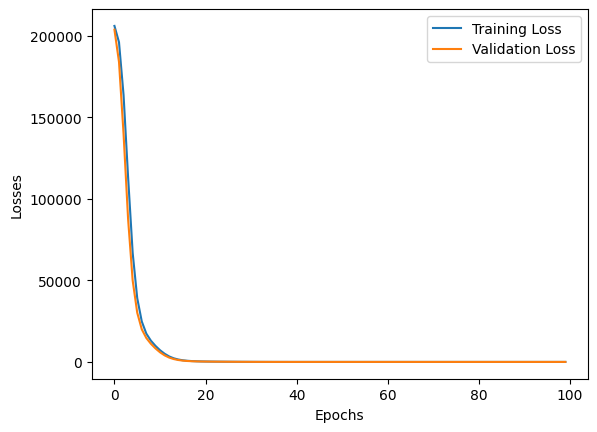

In [48]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"],label = "Training Loss")
plt.plot(loss_df["Validation Loss"],label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [49]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [51]:
# evaluation
model.eval()
with torch.no_grad():
  train_pred = model(x_train_tensor)
  test_pred = model(x_test_tensor)
  train_mse_loss = criterion(train_pred,y_train_tensor)
  test_mse_loss = criterion(test_pred,y_test_tensor)
print("Training MSE:", train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.719619750976562
Testing MSE: 18.93121337890625


In [52]:
from sklearn.metrics import r2_score
print("r2 score:",r2_score(y_test,test_pred))

r2 score: 0.9338402917174948


In [54]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns = ["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.752502,433.27
1,436.623535,438.16
2,461.499054,458.42
3,476.633148,480.82
4,435.123932,441.41
...,...,...
1909,451.123932,456.70
1910,431.211731,438.04
1911,467.397125,467.80
1912,430.675995,437.14
